# **Note for Colab Users**

# **Do not write directly in this file. Your work may disappear!**

# **Always make a copy before you start working.**

How to make a copy

1. Click “File” in the top-left corner  
> *If you cannot see menus like “File” or “Runtime”, click the “v” mark in the top-right corner to show them.*

2. Choose “Save a copy in Drive”  

3. Rename the copied file to “YOURNAMEs_FileName.ipynb”  
> Example: If your name is Olivia → Olivias_FileName.ipynb  


---

* Check marks (✅) are not saved. They disappear if you refresh the page with Chrome’s reload button.<br>  
If you stop partway through, add a text cell and write something like “SO FAR DONE”.

---

* In Colab, **previous outputs are reset every 30 to 90 minutes**.<br>  
So errors like `~~ is not defined` **happen very often**.

🔁 What should you do if you get a `~~ is not defined` error?

1. First, check the spelling of the variable name.<br>  
2. If the spelling is correct but the error still appears, **click that cell to select it**.<br>  
3. Click “Runtime” → “Run before” in the top-left menu.<br>  
→ This reruns **all cells before that cell**.  
4. Run that cell again.

If this still does not fix the error,<br>  
there may be a basic mistake in a TODO answer from an earlier cell.<br>  
Check whether it is correct.<br>  
Or ask ChatGPT or another coding assistant for help.

# **⚠️ This is a beta version**

You need some background knowledge about CLIP.

Chapter30 is currently a beta version. It does not include explanations or TODO problems yet.

Also, the model performance has not been evaluated yet.

Please read the code and evaluate the model performance yourself.

This early release comes from a change in the project’s communication policy: we will share progress in small pieces and talk about it more actively.

So there is no need to rush through it.

We will gradually add explanations and improve the notebook, so feel free to work on it then.

# **Chapter 30: Vision Pretraining**

In this Chapter, we extend the Instruction Tuning model into a VLM with Vision Pretraining.<br>

Next, we convert images into embeddings with CLIP and insert them as the first token embeddings of the LLM, extending the model so it can read images too.

### ⚠️ This assumes you have completed Chapter29 Magpie, which was added on 2026/6/5!

|  | Data | Model Output |
|---|---|---|
| Pretraining | Web data | Blog style |
| Instruction Tuning | Dialogue data | Dialogue style |
| Vision Pretraining | Images + captions/dialogue | Descriptions or answers based on images |


# References

LLaVA is an open-source Vision Language Model released in early 2023.

The original author seems to work at xAI now (2024/1/14). Pretty amazing.

https://github.com/haotian-liu/LLaVA.git

## **Section 1: Loading the Model**

We will use a G4 GPU again. You need at least 50 credits.

If you have no credits at all... please buy an extra 100 credits... 😭

**`Check Point`** <label><input type="checkbox">Confirmed that you connected to a G4 GPU<label>

The model class is the same as last time.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        # Define an embedding table with vocab size x embedding dimension
        self.token_embedding_table = nn.Embedding(vocab_size, embedding_dim)

    def embed(self, input_indices):
        # Get the embedding vectors for the input indices
        return self.token_embedding_table.forward(input_indices)


class RelativePositionEmbedding(nn.Module):
    def __init__(self, num_relative_positions: int):
        super().__init__()
        self.num_relative_positions = num_relative_positions
        self.bias_embedding_table = nn.Embedding(self.num_relative_positions, 1)

    def forward(self, query_len, key_len, device_type=None):
        query_positions = torch.arange(query_len, device=device_type)[:, None]  # (query_len, 1)
        key_positions = torch.arange(key_len, device=device_type)[None, :]      # (1, key_len)
        relative_position_matrix = query_positions - key_positions # key_positions - query_positions

        # Keep relative distances in the range [0, max_distance - 1] by clipping negative or too-large distances
        # (query_len, key_len)
        clamped_relative_position_matrix = relative_position_matrix.clamp(
            min=0, max=self.num_relative_positions - 1
        )

        # Get the matching bias vectors from the embedding layer
        # (query_len, key_len, 1)
        relative_position_bias_embeddings = self.bias_embedding_table(clamped_relative_position_matrix)

        # Remove the last dimension to make a matrix
        # (query_len, key_len)
        relative_position_bias_matrix = relative_position_bias_embeddings.squeeze(-1)

        return relative_position_bias_matrix


class AttentionHead(nn.Module):
    def __init__(self, head_size, config):
        super().__init__()
        self.key_fc= nn.Linear(config.embedding_dim, head_size, bias=False)
        self.query_fc = nn.Linear(config.embedding_dim, head_size, bias=False)
        self.value_fc = nn.Linear(config.embedding_dim, head_size, bias=False)

        self.head_size = head_size
        self.relative_position_embedding_layer = RelativePositionEmbedding(num_relative_positions=config.num_relative_positions)

    def forward(self, input_tensor):
        B, T, C = input_tensor.shape  # batch, token length, embedding channels

        Key = self.key_fc.forward(input_tensor)     # (B, T, head_size)
        Query = self.query_fc.forward(input_tensor)   # (B, T, head_size)
        Value = self.value_fc.forward(input_tensor)   # (B, T, head_size)

        # Calculate attention scores: (QK^T) / sqrt(embedding_dim)
        attention_weights_before_mask = Query @ Key.transpose(-2, -1) * self.head_size**(-0.5)

        # Calculate the relative position bias correction term
        relative_position_bias_matrix = self.relative_position_embedding_layer(T, T, device_type=input_tensor.device)

        # Add the relative position bias correction term
        attention_weights_before_mask = attention_weights_before_mask + relative_position_bias_matrix

        # Mask applied
        mask = torch.triu(torch.ones(T, T), diagonal=1).to(input_tensor.device)
        masked_attention_weights = attention_weights_before_mask.masked_fill(mask == 1, float('-inf'))

        # softmax → dropout → weighted sum
        attention_weights = F.softmax(masked_attention_weights, dim=-1)

        out = attention_weights @ Value  # (B, T, head_size)
        return out


class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.num_attention_heads = config.num_attention_heads
        self.embedding_dim = config.embedding_dim
        self.head_size = int(self.embedding_dim / self.num_attention_heads)

        # Manage multiple heads with ModuleList
        self.attention_heads = nn.ModuleList([
            AttentionHead(self.head_size, config)
            for _ in range(self.num_attention_heads)
        ])

        # Linear layer that mixes the outputs from each head
        self.output_projection = nn.Linear(self.embedding_dim, self.embedding_dim)


    def forward(self, input_tensor):
        # Get the output from each head
        # List of (B, T, head_size)
        head_outputs_list = [head.forward(input_tensor) for head in self.attention_heads]

        # Concatenate all head outputs → (B, T, embedding_dim)
        concatenated = torch.cat(head_outputs_list, dim=-1)

        # Mix outputs with a linear transformation
        projected = self.output_projection.forward(concatenated)

        return projected

class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.embedding_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.embedding_dim),
        )

    def forward(self, input_tensor):
        return self.net(input_tensor)

class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()

        # Each LayerNorm keeps its own beta and gamma.
        self.layer_norm1 = nn.LayerNorm(config.embedding_dim)
        self.layer_norm2 = nn.LayerNorm(config.embedding_dim)

        self.multihead_attention = MultiHeadAttention(config=config)
        self.feed_forward = FeedForward(config=config)

    def forward(self, input_tensor):
        # The forward method is omitted.
        normed_input = self.layer_norm1(input_tensor) # Apply layer norm to the input
        attention_output = self.multihead_attention(normed_input) # Apply multi-head attention
        residual_attention = attention_output + input_tensor # Add "before! layernorm1"
        normed_attention = self.layer_norm2(residual_attention) # Apply LayerNorm again to the residual output
        feedforward_output = self.feed_forward(normed_attention) # Apply the feed-forward network
        final_output = feedforward_output + residual_attention # Add "before" layernorm2!

        return final_output

class VocabularyLogits(nn.Module):
    def __init__(self, vocab_size, config):
        super().__init__()
        # Layer normalization
        self.output_norm = nn.LayerNorm(config.embedding_dim)
        # Vocabulary-size projection
        self.vocab_projection = nn.Linear(config.embedding_dim, vocab_size)

    def forward(self, transformer_block_output):
        # Apply Layer normalization to the Transformer block output.
        normalized_output = self.output_norm.forward(transformer_block_output)  # (B, T, C)

        # Convert scores to the vocabulary dimension with a linear layer.
        vocab_logits = self.vocab_projection.forward(normalized_output)  # (B, T, V)

        return vocab_logits


In [ ]:
class EveryonesGPT(nn.Module):
    def __init__(self, vocab_size, config):
        super().__init__()
        self.config = config  # Keep this because it is also used during generation.
        self.token_embedding_layer = TokenEmbedding(vocab_size = vocab_size, embedding_dim = config.embedding_dim)
        self.blocks = nn.Sequential(*[TransformerBlock(config=config) for _ in range(config.layer_count)])
        self.vocab_projection = VocabularyLogits(vocab_size=vocab_size, config=config)
        # Do not calculate loss where target is -100
        self.criterion = nn.CrossEntropyLoss(ignore_index=-100)

    # Calculate logits and loss
    def forward(self, input_indices, target_indices):
        token_embeddings = self.token_embedding_layer.embed(input_indices)
        blocks_output = self.blocks(token_embeddings)
        logits = self.vocab_projection(blocks_output)

        # During inference there is no target, so loss is None
        # Only probabilities (logits) are returned.
        if target_indices is None:
            return logits, None

        batch_size, token_len, vocab_size = logits.shape
        logits = logits.view(batch_size * token_len, vocab_size)
        targets = target_indices.view(batch_size * token_len)
        loss = self.criterion(logits, targets)

        return logits, loss

    # Generate text
    def generate(self, input_indices, max_new_tokens, temperature=1.0):
        # Generate only the specified number of tokens, max_new_tokens
        for _ in range(max_new_tokens):
            input_conditioned = input_indices[:, -self.config.input_sequence_length:] # Crop the input

            # The forward pass returns `(likelihood, loss)`, so keep only `likelihood` as `logits`.
            logits, _ = self.forward(input_conditioned, target_indices=None)
            last_logits = logits[:, -1, :] # Extract the logits for the last token
            last_logits = last_logits / temperature
            probs = F.softmax(last_logits, dim=-1) # Convert logits into probabilities with softmax

            # Sample the next token
            next_token = torch.multinomial(probs, num_samples=1)

            # Append the new token and update input_indices.
            input_indices = torch.cat((input_indices, next_token), dim=1)

        # Return the final `input_indices`. Its length is the original `input_indices` plus `max_new_tokens`.
        return input_indices

The Config class is also the same as last time.

In [ ]:
class Config:
    # === training ===
    batch_size: int = 32 # 85GB VRAM
    total_training_steps: int = 100_000
    checkpoint_save_frequency: int = 10_000
    input_sequence_length: int = 1024

    # === model ===
    embedding_dim: int = 1280
    hidden_dim: int = 5120
    num_attention_heads: int = 10
    layer_count: int = 20
    num_relative_positions = 1024

    # === optimization ===
    max_learning_rate: float = 2e-4
    min_learning_rate: float = 2e-5
    warmup_steps: int = 1_000

    # === system ===
    device_type: str = "cuda"

In [ ]:
config = Config()

Create a model instance. At this point, the model parameters, such as weights and biases, are initialized randomly.

So we do not move it to the GPU yet. We move it to the GPU after loading the pretrained model parameter values.

In [ ]:
vocab_size = 50257
# Do not move it to the GPU yet.
model = EveryonesGPT(vocab_size = vocab_size, config = config)

Log in to HuggingFace.

In [ ]:
from huggingface_hub import login
login()

Download only the weights of the Instruction Tuning model.

In [ ]:
from huggingface_hub import hf_hub_download
model_repo_id = # TODO: Replace this with your own repo. This is the repository saved in Chapter29.
checkpoint_path = # TODO: Replace this with your own checkpoint. Example: "checkpoints-prompt-mask-instruction-tuning/checkpoint_010000.pt"

hf_hub_download(
    repo_id=model_repo_id,
    repo_type="model",
    filename=checkpoint_path,
    local_dir=".",
)

'checkpoints-instruction-tuning/checkpoint_010000.pt'

In [ ]:
checkpoint_data = torch.load(checkpoint_path, map_location="cpu")

In [ ]:
state_dict = checkpoint_data["model_state_dict"]
new_state_dict = {k.replace("_orig_mod.", ""): v for k, v in state_dict.items()}
model.load_state_dict(new_state_dict)

<All keys matched successfully>

The Instruction Tuning model parameter values have now been loaded into the model instance.

Now move it onto the GPU.

In [ ]:
model.to("cuda")

EveryonesGPT(
  (token_embedding_layer): TokenEmbedding(
    (token_embedding_table): Embedding(50257, 1280)
  )
  (blocks): Sequential(
    (0): TransformerBlock(
      (layer_norm1): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
      (layer_norm2): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
      (multihead_attention): MultiHeadAttention(
        (attention_heads): ModuleList(
          (0-9): 10 x AttentionHead(
            (key_fc): Linear(in_features=1280, out_features=128, bias=False)
            (query_fc): Linear(in_features=1280, out_features=128, bias=False)
            (value_fc): Linear(in_features=1280, out_features=128, bias=False)
            (relative_position_embedding_layer): RelativePositionEmbedding(
              (bias_embedding_table): Embedding(1024, 1)
            )
          )
        )
        (output_projection): Linear(in_features=1280, out_features=1280, bias=True)
      )
      (feed_forward): FeedForward(
        (net): Sequential(
 

Let’s check inference with the Instruction Tuning model!

The sampling parameter `temperature` is set to 0.7 during inference.

Because of this, the LLM output has relatively high randomness.

Run inference 5 times and check the output pattern.

In [ ]:
import tiktoken

model.eval()
prompt = "<USER>What is the chemical symbol for silver?<AI>"
tokenizer = tiktoken.get_encoding("gpt2")
encoded = tokenizer.encode(prompt, allowed_special="all") # Encode text into IDs
encoded_tensor = torch.tensor(encoded, dtype=torch.long) # Convert the list of IDs into a tensor
encoded_tensor = encoded_tensor.unsqueeze(0)  # Add a batch dimension
encoded_tensor = encoded_tensor.to(config.device_type) # Move encoded_tensor to cuda (GPU)
generated_tensor = model.generate(encoded_tensor, max_new_tokens=64, temperature=0.7)
generated_ids = generated_tensor.squeeze(0).tolist() # Remove the batch dimension and convert to a list
generated_text = tokenizer.decode(generated_ids) # Decode the list of IDs into text
print(generated_text)

<USER>What is the chemical symbol for silver?<AI>The chemical symbol for silver is Silver.<|endoftext|>techne.<|endoftext|>1. **Chemical Symbol:** Silver
2. **Chemical Symbol:** Silver
3. **Chemical Symbol:** Silver
4. **Chemical Symbol:** Silver
5. **Chemical Symbol:** Silver
6


**`Check Point`** <label><input type="checkbox">Ran inference 5 times and checked the output pattern.<label>

## **Section 3: Extending to Vision Pretraining**

From here, we extend the Instruction Tuning version of EveryonesGPT into a Vision Language Model.<br>
The key idea is very simple.

- We do not add images to the tokenizer.
- We do not create a new loss for images.
- We freeze the LLM itself and the CLIP Vision Encoder.
- The only part we train is the Projector, which converts CLIP image features into the LLM embedding dimension.
- We reuse the `-100` mask from Instruction Tuning for image-based data too.

In other words, we treat an image as “256 embeddings placed before the text.”<br>
Then we remove the loss for the question and image patch parts with `-100`, and train only on the answer part.

This is the same idea as LLaVA pretraining.

### **Things We Can Actually Skip**

When you hear the name VLM, it is tempting to add some huge mechanism.<br>
But in this material, we skip the following as a first step.

- **Adding image-only tokens**: A temporary PAD token is enough if we replace only its embedding with image features.
- **Retraining CLIP**: The image features are already strong, so we freeze CLIP.
- **Retraining the whole LLM**: We freeze it to protect the language ability learned through Instruction Tuning.
- **KV cache / streaming**: These are tools for faster inference, not required for understanding Vision Pretraining.
- **Complex chat templates**: For now, `<USER>{prompt}<AI>{response}` is enough.

For beginners, the important part is to think separately about “where to show the image” and “where to calculate the loss.”

In [ ]:
# Run this only once in Colab.
# Used for CLIPVisionModel / CLIPImageProcessor and extracting image files.
!pip -q install transformers pillow zstandard
!apt-get -qq update
!apt-get -qq install -y zstd unzip wget

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package zstd.
(Reading database ... 122402 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...


Define constants for vision.

CLIP ViT-L/14 converts a 224x224 image into 16x16 = 256 patch features.<br>
We insert these 256 image patches into the first 256 positions of the text sequence.

`IGNORE_INDEX = -100` is the same value we used in Instruction Tuning.

In [ ]:
PAD_TOKEN_ID = 50256
IGNORE_INDEX = -100
NUM_IMAGE_PATCHES = 256
VISION_PROJECTOR_HIDDEN_DIM = 2048
VISION_ENCODER = "openai/clip-vit-large-patch14"

Define the Vision Language Model.

`llm` is the `model` that we Instruction Tuned up to this point.<br>
Only the first `NUM_IMAGE_PATCHES` token embeddings are replaced with image embeddings made by the Projector.

We do not decide which parameters to train inside this class.<br>
Later, in the optimizer settings, we choose whether to train CLIP, the Projector, and/or the LLM.

In [ ]:
from transformers import CLIPVisionModel

class VLM(nn.Module):
    def __init__(self, llm):
        super().__init__()
        self.llm = llm

        # Use the CLIP Vision Encoder as an image feature extractor.
        self.vision = CLIPVisionModel.from_pretrained(VISION_ENCODER)

        # Projector that converts CLIP image features into the LLM embedding dimension.
        self.projector = nn.Sequential(
            nn.Linear(self.vision.config.hidden_size, VISION_PROJECTOR_HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(VISION_PROJECTOR_HIDDEN_DIM, llm.config.embedding_dim),
        )

        self.loss_fn = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)

    def make_multimodal_embeddings(self, image_batch, input_token_ids):
        text_embeddings = self.llm.token_embedding_layer.embed(input_token_ids)

        # Freeze CLIP parameters before creating the optimizer.
        vision_outputs = self.vision(image_batch, output_hidden_states=True)
        image_features = vision_outputs.hidden_states[-1][:, 1:]
        image_embeddings = self.projector(image_features)

        # Replace the first NUM_IMAGE_PATCHES token embeddings with image embeddings.
        multimodal_embeddings = torch.cat(
            [image_embeddings, text_embeddings[:, NUM_IMAGE_PATCHES:]],
            dim=1,
        )
        return multimodal_embeddings

    def forward_logits(self, image_batch, input_token_ids):
        multimodal_embeddings = self.make_multimodal_embeddings(image_batch, input_token_ids)
        blocks_output = self.llm.blocks(multimodal_embeddings)
        logits = self.llm.vocab_projection(blocks_output)
        return logits

    def forward(self, image_batch, input_token_ids, target_labels):
        logits = self.forward_logits(image_batch, input_token_ids)

        batch_size, token_len, vocab_size = logits.shape
        loss = self.loss_fn(
            logits.view(batch_size * token_len, vocab_size),
            target_labels.view(batch_size * token_len),
        )

        return logits, loss

Wrap the Instruction Tuning `model` inside the VLM.

Wrap the original `model`, not `compiled_model`.<br>
For saving and converting into a VLM, the model before compile is easier to handle.

In [ ]:
model.eval()
vision_model = VLM(model).to(config.device_type)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

CLIPVisionModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight       

In [ ]:
# Compile the full VLM to speed up training
# ⚠️ Don't run this cell twice!
torch.backends.cuda.matmul.allow_tf32 = True
torch.set_float32_matmul_precision("high")
compiled_vision_model = torch.compile(vision_model)

Prepare the vision dataset.

For chat, we use a JSONL file that has already been aligned to a shared template.

```json
{"image_file": "...", "user": "...", "assistant": "..."}
```

In this notebook, we read the shared chat JSONL and create `image_path` by joining the image file name with the image folder.<br>
The processing after that is the same for Vision Pretraining and Vision Instruction Tuning.

In [ ]:
from huggingface_hub import snapshot_download

snapshot_download(
    repo_id="HayatoHongo/LLaVA-CC3M-Pretrain-521K",
    repo_type="dataset",
    local_dir="/content/llava_cc3m_pretrain_521k",
    allow_patterns=["vision_pretraining_chat_unified.jsonl", "images.tar.zst"],
)

print("chat:", "/content/llava_cc3m_pretrain_521k/vision_pretraining_chat_unified.jsonl")
print("images archive:", "/content/llava_cc3m_pretrain_521k/images.tar.zst")
print("image folder after extraction:", "/content/llava_cc3m_pretrain_521k/images/images_protect/images2")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

chat: /content/llava_cc3m_pretrain_521k/vision_pretraining_chat_unified.jsonl
images archive: /content/llava_cc3m_pretrain_521k/images.tar.zst
image folder after extraction: /content/llava_cc3m_pretrain_521k/images/images_protect/images2


Extract the image archive.

Because we are extracting a large number of image files, we use `zstd -T0 | tar` instead of Python.<br>

This takes about 8 to 10 minutes.

It takes a while, so please wait.

In [ ]:
%%capture
!mkdir -p /content/llava_cc3m_pretrain_521k/images
!zstd -T0 -dc /content/llava_cc3m_pretrain_521k/images.tar.zst \
  | tar -x -C /content/llava_cc3m_pretrain_521k/images

In [ ]:
import json
import os

unified_chat_file = open("/content/llava_cc3m_pretrain_521k/vision_pretraining_chat_unified.jsonl", "r", encoding="utf-8")
training_text_file = open("/content/vision_text_pairs.jsonl", "w", encoding="utf-8")

sample_count = 0
for chat_json_line in unified_chat_file:
    chat_sample = json.loads(chat_json_line)

    training_text_sample = {
        "image_path": os.path.join("/content/llava_cc3m_pretrain_521k/images/images_protect/images2", chat_sample["image_file"]),
        "prompt_text": "<USER>" + chat_sample["user"] + "<AI>",
        "response_text": chat_sample["assistant"] + "<|endoftext|>",
    }
    training_text_file.write(json.dumps(training_text_sample, ensure_ascii=False) + "\n")
    sample_count += 1

unified_chat_file.close()
training_text_file.close()

print("saved:", "/content/vision_text_pairs.jsonl")
print("samples:", sample_count)

saved: /content/vision_text_pairs.jsonl
samples: 521031


In [ ]:
text_pairs_file = open("/content/vision_text_pairs.jsonl", "r", encoding="utf-8")

print(text_pairs_file.readline().rstrip())
print(text_pairs_file.readline().rstrip())
print(text_pairs_file.readline().rstrip())

text_pairs_file.close()

{"image_path": "/content/llava_cc3m_pretrain_521k/images/images_protect/images2/GCC_train_002582585.jpg", "prompt_text": "<USER>Provide a brief description of the given image.<AI>", "response_text": "olive oil is a healthy ingredient used liberally .<|endoftext|>"}
{"image_path": "/content/llava_cc3m_pretrain_521k/images/images_protect/images2/GCC_train_002429825.jpg", "prompt_text": "<USER>Write a terse but informative summary of the picture.<AI>", "response_text": "3d vector deluxe alphabet of randomly rotated thin golden symbols .<|endoftext|>"}
{"image_path": "/content/llava_cc3m_pretrain_521k/images/images_protect/images2/GCC_train_000190697.jpg", "prompt_text": "<USER>Share a concise interpretation of the image provided.<AI>", "response_text": "weathering -- the physical & chemical breakdown of rocks .<|endoftext|>"}


In [ ]:
import json
import numpy as np
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
max_sequence_length = config.input_sequence_length

image_path_list = []
input_token_ids_list = []
target_labels_list = []

text_pairs_file = open("/content/vision_text_pairs.jsonl", "r", encoding="utf-8")

for text_pair_json_line in text_pairs_file:
    training_text_sample = json.loads(text_pair_json_line)

    image_path = training_text_sample["image_path"]
    prompt_text = training_text_sample["prompt_text"]
    response_text = training_text_sample["response_text"]

    prompt_token_ids = tokenizer.encode(prompt_text, allowed_special="all")
    response_token_ids = tokenizer.encode(response_text, allowed_special={"<|endoftext|>"})

    image_placeholder_token_ids = [PAD_TOKEN_ID] * NUM_IMAGE_PATCHES
    full_token_ids = image_placeholder_token_ids + prompt_token_ids + response_token_ids
    full_target_labels = [IGNORE_INDEX] * NUM_IMAGE_PATCHES + [IGNORE_INDEX] * len(prompt_token_ids) + response_token_ids

    # Because we shift, keep full_token_ids up to input_sequence_length + 1.
    full_token_ids = full_token_ids[:max_sequence_length + 1]
    full_target_labels = full_target_labels[:max_sequence_length + 1]

    input_token_ids = full_token_ids[:-1]
    target_labels = full_target_labels[1:]

    padding_token_count = max_sequence_length - len(input_token_ids)
    input_token_ids = input_token_ids + [PAD_TOKEN_ID] * padding_token_count
    target_labels = target_labels + [IGNORE_INDEX] * padding_token_count

    image_path_list.append(image_path)
    input_token_ids_list.append(input_token_ids)
    target_labels_list.append(target_labels)

text_pairs_file.close()

input_token_ids_numpy = np.array(input_token_ids_list, dtype=np.int32)
target_labels_numpy = np.array(target_labels_list, dtype=np.int32)

image_paths_file = open("/content/vision_image_paths.json", "w", encoding="utf-8")
json.dump(image_path_list, image_paths_file, ensure_ascii=False)
image_paths_file.close()

np.save("/content/vision_input_ids.npy", input_token_ids_numpy)
np.save("/content/vision_labels.npy", target_labels_numpy)

print("images:", len(image_path_list))
print("input_ids:", input_token_ids_numpy.shape)
print("labels:", target_labels_numpy.shape)

images: 521031
input_ids: (521031, 1024)
labels: (521031, 1024)


Define the DataLoader for vision.

Since preprocessing is already done, the DataLoader has much less work to do.

- Randomly choose row numbers
- Open images
- Take out `input_ids` and `labels`
- Convert them to tensors and send them to the GPU

We no longer parse conversations, tokenize, create masks, or pad here.

In [ ]:
from PIL import Image
from transformers import CLIPImageProcessor

class VisionDataLoader:
    def __init__(self, image_paths_file_path, input_ids_file_path, labels_file_path, config):
        self.config = config
        self.image_processor = CLIPImageProcessor.from_pretrained(VISION_ENCODER)

        image_paths_file = open(image_paths_file_path, "r", encoding="utf-8")
        self.image_paths = json.load(image_paths_file)
        image_paths_file.close()

        self.input_token_ids = np.load(input_ids_file_path, mmap_mode="r")
        self.target_labels = np.load(labels_file_path, mmap_mode="r")

    def get_batch(self):
        sample_count = len(self.image_paths)
        sample_indices = torch.randint(sample_count, (self.config.batch_size,)).tolist()

        pil_images = []
        for sample_index in sample_indices:
            pil_image = Image.open(self.image_paths[sample_index]).convert("RGB")
            pil_images.append(pil_image)

        image_batch = self.image_processor(images=pil_images, return_tensors="pt")["pixel_values"]
        input_token_ids = torch.tensor(self.input_token_ids[sample_indices], dtype=torch.long)
        target_labels = torch.tensor(self.target_labels[sample_indices], dtype=torch.long)

        return (
            image_batch.to(self.config.device_type),
            input_token_ids.to(self.config.device_type),
            target_labels.to(self.config.device_type),
        )

vision_data_loader = VisionDataLoader(
    image_paths_file_path="/content/vision_image_paths.json",
    input_ids_file_path="/content/vision_input_ids.npy",
    labels_file_path="/content/vision_labels.npy",
    config=config,
)

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

In [ ]:
def get_learning_rate(current_step, config):
    max_learning_rate = config.max_learning_rate
    min_learning_rate = config.min_learning_rate
    warmup_steps = config.warmup_steps
    total_training_steps = config.total_training_steps

    if current_step < warmup_steps:
        # --- Linear Warmup ---
        warmup_progress_ratio = current_step / warmup_steps
        learning_rate = max_learning_rate * warmup_progress_ratio

    else:
        # --- Linear Decay ---
        decay_total_steps = total_training_steps - warmup_steps
        decay_step_index = current_step - warmup_steps

        decay_progress_ratio = decay_step_index / decay_total_steps
        learning_rate_range = max_learning_rate - min_learning_rate
        learning_rate = max_learning_rate - learning_rate_range * decay_progress_ratio

    return learning_rate


Define the Trainer for vision.

The only difference from a normal Trainer is that each batch has three parts: `images, input_ids, labels`.<br>
We use the same Trainer for Vision Pretraining and Vision Instruction Tuning.

In [ ]:
import time
import os
from huggingface_hub import create_repo
from huggingface_hub import upload_file

class VisionTrainer:
    def __init__(self, model, optimizer, data_loader, config, checkpoint_dir, checkpoint_name, repo_id):
        self.model = model
        self.optimizer = optimizer
        self.data_loader = data_loader
        self.config = config
        self.checkpoint_dir = checkpoint_dir
        self.checkpoint_name = checkpoint_name
        self.repo_id = repo_id

        self.steps = []
        self.learning_rates = []
        self.train_losses = []
        self.tokens_per_second_list = []
        self.total_seen_tokens_list = []
        self.total_train_time_list = []

    def train_step(self):
        image_batch, input_token_ids, target_labels = self.data_loader.get_batch()
        self.optimizer.zero_grad()
        # Model forward pass and loss calculation
        with torch.autocast(device_type=self.config.device_type, dtype=torch.bfloat16):
            logits, loss = self.model(image_batch, input_token_ids, target_labels)
        loss.backward()
        self.optimizer.step()
        return loss.item()

    def save_checkpoint(self, step):
        os.makedirs(self.checkpoint_dir, exist_ok=True)
        checkpoint_path = os.path.join(
            self.checkpoint_dir,
            f"checkpoint_{step:06d}_{self.checkpoint_name}.pt",
        )
        checkpoint_data = {
            "model_state_dict": self.model.state_dict(),
            "optimizer_state_dict": self.optimizer.state_dict(),
            "config": config_dict,
            "current_step": step,
            "vision_encoder": VISION_ENCODER,
            "num_image_patches": NUM_IMAGE_PATCHES,
            "vision_projector_hidden_dim": VISION_PROJECTOR_HIDDEN_DIM,
        }
        torch.save(checkpoint_data, checkpoint_path)
        return checkpoint_path

    def train(self):
        total_train_time = 0
        last_log_time = time.time()

        for step in range(1, self.config.total_training_steps + 1):
            self.optimizer.param_groups[0]["lr"] = get_learning_rate(step, self.config)
            train_loss = self.train_step()

            if step % self.config.checkpoint_save_frequency == 0:
                checkpoint_path = self.save_checkpoint(step)
                create_repo(repo_id=self.repo_id, private=False, exist_ok=True)
                upload_file(
                    repo_id=self.repo_id,
                    repo_type="model",
                    path_or_fileobj=checkpoint_path,
                    path_in_repo=os.path.basename(checkpoint_path),
                )

            current_log_time = time.time()
            interval_seconds = current_log_time - last_log_time
            total_train_time += interval_seconds

            tokens_per_interval = self.config.batch_size * self.config.input_sequence_length
            tokens_per_second = tokens_per_interval / interval_seconds
            total_seen_tokens = self.config.batch_size * self.config.input_sequence_length * step
            current_learning_rate = self.optimizer.param_groups[0]["lr"]

            print(
                f"step {step:05d} | ",
                f"lr {current_learning_rate:.6e} | ",
                f"train loss {train_loss:.4f} | ",
                f"tok/s {int(tokens_per_second)} | ",
                f"tokens {total_seen_tokens:,} | ",
                f"time {total_train_time:.2f}s",
            )

            self.steps.append(step)
            self.learning_rates.append(current_learning_rate)
            self.train_losses.append(train_loss)
            self.tokens_per_second_list.append(tokens_per_second)
            self.total_seen_tokens_list.append(total_seen_tokens)
            self.total_train_time_list.append(total_train_time)

            last_log_time = current_log_time

Create the training settings and optimizer.

This is the first place where we decide which parameters to train.<br>
In Vision Pretraining, we freeze the LLM. In Vision Instruction Tuning, we train the LLM too.

In [ ]:
config.batch_size = 24
config.total_training_steps = 20_000
config.checkpoint_save_frequency = 5_000
config.max_learning_rate = 1e-3
config.min_learning_rate = 1e-4
config.warmup_steps = 500

config_dict = {
    "batch_size": config.batch_size,
    "total_training_steps": config.total_training_steps,
    "checkpoint_save_frequency": config.checkpoint_save_frequency,
    "input_sequence_length": config.input_sequence_length,
    "embedding_dim": config.embedding_dim,
    "hidden_dim": config.hidden_dim,
    "num_attention_heads": config.num_attention_heads,
    "layer_count": config.layer_count,
    "num_relative_positions": config.num_relative_positions,
    "max_learning_rate": config.max_learning_rate,
    "min_learning_rate": config.min_learning_rate,
    "warmup_steps": config.warmup_steps,
    "device_type": config.device_type,
}

# Since CLIP is used as an image feature extractor, freeze it for both training modes.
for parameter in compiled_vision_model.vision.parameters():
    parameter.requires_grad = False

# Train the Projector to map image features into the LLM embedding space.
for parameter in compiled_vision_model.projector.parameters():
    parameter.requires_grad = True

# In Vision Pretraining, protect the LLM. In Vision Instruction Tuning, also tune how it answers.
for parameter in compiled_vision_model.llm.parameters():
    parameter.requires_grad = False

vision_optimizer = torch.optim.AdamW(
    compiled_vision_model.parameters(),
    lr=config.max_learning_rate,
    betas=(0.9, 0.95),
    weight_decay=0.0,
    fused=True,
)

In [ ]:
model_repo_id = # TODO: FILL Create a new repository. # Example: "HayatoHongo/EveryonesGPT-VisionPretrained"

In [ ]:
compiled_vision_model.train()
compiled_vision_model.vision.eval()
compiled_vision_model.llm.train(mode=False)

vision_trainer = VisionTrainer(
    model=compiled_vision_model,
    optimizer=vision_optimizer,
    data_loader=vision_data_loader,
    config=config,
    checkpoint_name="vision_pretraining",
    checkpoint_dir="./checkpoints-vision-pretraining",
    repo_id=model_repo_id,
)

This will be a long training run of about 180 minutes, or 3 hours.

The Trainer does not yet have resume code, so if the runtime stops, that run is over.
(Because this is still a beta version, it has rough edges like this... 🙇‍♂️ We will improve it step by step.)

That said, it should be set to save and upload to HuggingFace every 5,000 steps.

Be careful not to accidentally close your computer.


In [ ]:
torch.manual_seed(42)
vision_trainer.train()

step 00001 |  lr 2.000000e-06 |  train loss 7.8739 |  tok/s 3060 |  tokens 24,576 |  time 8.03s
step 00002 |  lr 4.000000e-06 |  train loss 8.1074 |  tok/s 1891 |  tokens 49,152 |  time 21.02s
step 00003 |  lr 6.000000e-06 |  train loss 7.8876 |  tok/s 46003 |  tokens 73,728 |  time 21.55s
step 00004 |  lr 8.000000e-06 |  train loss 7.5491 |  tok/s 45923 |  tokens 98,304 |  time 22.09s
step 00005 |  lr 1.000000e-05 |  train loss 7.3617 |  tok/s 45993 |  tokens 122,880 |  time 22.62s
step 00006 |  lr 1.200000e-05 |  train loss 7.7615 |  tok/s 45913 |  tokens 147,456 |  time 23.16s
step 00007 |  lr 1.400000e-05 |  train loss 7.7229 |  tok/s 45955 |  tokens 172,032 |  time 23.69s
step 00008 |  lr 1.600000e-05 |  train loss 7.4970 |  tok/s 46097 |  tokens 196,608 |  time 24.23s
step 00009 |  lr 1.800000e-05 |  train loss 7.3025 |  tok/s 46050 |  tokens 221,184 |  time 24.76s
step 00010 |  lr 2.000000e-05 |  train loss 7.3035 |  tok/s 46005 |  tokens 245,760 |  time 25.29s
step 00011 |  lr 

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...5000_vision_pretrained.pt:   0%|          |  557kB / 3.36GB            

step 05000 |  lr 7.923077e-04 |  train loss 4.1187 |  tok/s 908 |  tokens 122,880,000 |  time 2743.53s
step 05001 |  lr 7.922615e-04 |  train loss 4.4038 |  tok/s 46007 |  tokens 122,904,576 |  time 2744.06s
step 05002 |  lr 7.922154e-04 |  train loss 4.2113 |  tok/s 45953 |  tokens 122,929,152 |  time 2744.60s
step 05003 |  lr 7.921692e-04 |  train loss 4.4344 |  tok/s 46035 |  tokens 122,953,728 |  time 2745.13s
step 05004 |  lr 7.921231e-04 |  train loss 4.5072 |  tok/s 46015 |  tokens 122,978,304 |  time 2745.66s
step 05005 |  lr 7.920769e-04 |  train loss 4.3886 |  tok/s 45996 |  tokens 123,002,880 |  time 2746.20s
step 05006 |  lr 7.920308e-04 |  train loss 4.2650 |  tok/s 45974 |  tokens 123,027,456 |  time 2746.73s
step 05007 |  lr 7.919846e-04 |  train loss 4.2979 |  tok/s 45952 |  tokens 123,052,032 |  time 2747.27s
step 05008 |  lr 7.919385e-04 |  train loss 3.9722 |  tok/s 46008 |  tokens 123,076,608 |  time 2747.80s
step 05009 |  lr 7.918923e-04 |  train loss 4.3675 |  tok

...

step 15000 |  lr 3.307692e-04 |  train loss 4.1779 |  tok/s 2015 |  tokens 368,640,000 |  time 8147.51s
step 15001 |  lr 3.307231e-04 |  train loss 3.9705 |  tok/s 45914 |  tokens 368,664,576 |  time 8148.04s
step 15002 |  lr 3.306769e-04 |  train loss 3.8418 |  tok/s 46005 |  tokens 368,689,152 |  time 8148.58s
step 15003 |  lr 3.306308e-04 |  train loss 4.4367 |  tok/s 45829 |  tokens 368,713,728 |  time 8149.11s
step 15004 |  lr 3.305846e-04 |  train loss 3.9652 |  tok/s 45917 |  tokens 368,738,304 |  time 8149.65s
step 15005 |  lr 3.305385e-04 |  train loss 4.2635 |  tok/s 45982 |  tokens 368,762,880 |  time 8150.18s
step 15006 |  lr 3.304923e-04 |  train loss 4.1666 |  tok/s 45887 |  tokens 368,787,456 |  time 8150.72s
step 15007 |  lr 3.304462e-04 |  train loss 4.3461 |  tok/s 45907 |  tokens 368,812,032 |  time 8151.26s
step 15008 |  lr 3.304000e-04 |  train loss 3.7852 |  tok/s 45948 |  tokens 368,836,608 |  time 8151.79s
step 15009 |  lr 3.303538e-04 |  train loss 4.2235 |  to

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...0000_vision_pretrained.pt:   8%|7         |  256MB / 3.36GB            

step 20000 |  lr 1.000000e-04 |  train loss 4.1211 |  tok/s 1631 |  tokens 491,520,000 |  time 10861.12s


Save the vision model.<br>
Here, we save the `state_dict` for the whole VLM. During inference, we create the same VLM class and load these weights.

Even if you trained up to 20,000 steps and then the runtime died, that is okay.

At the beginning of the next Chapter31, we will run inference from the checkpoint.

Chapter30 ends here. Please move on to Chapter31.

In [ ]:
torch.save(
    {
        "model_state_dict": vision_model.state_dict(),
        "config": config_dict,
        "vision_encoder": VISION_ENCODER,
        "num_image_patches": NUM_IMAGE_PATCHES,
        "vision_projector_hidden_dim": VISION_PROJECTOR_HIDDEN_DIM,
    },
    "vision_pretrained_model.pt",
)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  vision_pretrained_model.pt  :   3%|3         |  104MB / 3.32GB            

CommitInfo(commit_url='https://huggingface.co/HayatoHongo/EveryonesGPT-VisionPretrained-checkpoints20260528/commit/19df0690f5bf003cee43a44b023b110125b74afc', commit_message='Upload vision_pretrained_model_base99000_it10000_vp20000_2048relu.pt with huggingface_hub', commit_description='', oid='19df0690f5bf003cee43a44b023b110125b74afc', pr_url=None, repo_url=RepoUrl('https://huggingface.co/HayatoHongo/EveryonesGPT-VisionPretrained-checkpoints20260528', endpoint='https://huggingface.co', repo_type='model', repo_id='HayatoHongo/EveryonesGPT-VisionPretrained-checkpoints20260528'), pr_revision=None, pr_num=None)

In [ ]:
upload_file(repo_id=model_repo_id, repo_type="model", path_or_fileobj="vision_pretrained_model.pt", path_in_repo="vision_pretrained_model.pt")

Let’s look at the training curve.

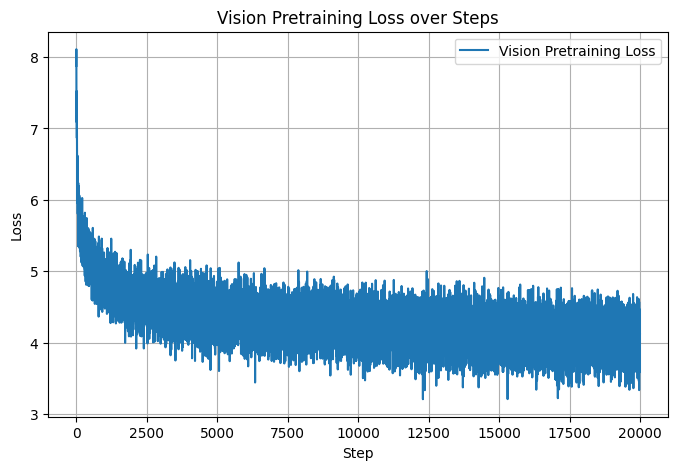

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(vision_trainer.steps, vision_trainer.train_losses, label="Vision Pretraining Loss")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Vision Pretraining Loss over Steps")
plt.legend()
plt.grid(True)
plt.show()

### **Inference with the Vision Model**

Finally, let’s check image-based inference.<br>
To keep the idea easy to understand, we use simple generation without KV cache.

In [ ]:
!wget -q https://raw.githubusercontent.com/HayatoHongo/nanoGPTVision/main/hodomoe_cat.png -O /content/hodomoe_cat.png

In [ ]:
from PIL import Image
from transformers import CLIPImageProcessor

image_processor = CLIPImageProcessor.from_pretrained(VISION_ENCODER)
image = Image.open("/content/hodomoe_cat.png").convert("RGB")
image_tensor = image_processor(images=image, return_tensors="pt")["pixel_values"].to(config.device_type)

In [ ]:
@torch.no_grad()
def vlm_generate(model, image_tensor, input_token_ids, max_new_tokens, temperature=1.0):
    model.eval()

    # Generate only the specified number of tokens, max_new_tokens
    for _ in range(max_new_tokens):
        input_conditioned = input_token_ids[:, -model.llm.config.input_sequence_length:] # Crop the input

        # The forward pass returns logits.
        logits = model.forward_logits(image_tensor, input_conditioned)
        last_logits = logits[:, -1, :] # Extract the logits for the last token
        last_logits = last_logits / temperature
        probs = F.softmax(last_logits, dim=-1) # Convert logits into probabilities with softmax

        # Sample the next token
        next_token = torch.multinomial(probs, num_samples=1)

        # Append the new token and update input_token_ids.
        input_token_ids = torch.cat((input_token_ids, next_token), dim=1)

    # Return the final `input_token_ids`. Its length is the original `input_token_ids` plus `max_new_tokens`.
    return input_token_ids

LLMs are probabilistic. Please run inference 5 times.

Words like “cat” and “green background” should appear.

However, each output will probably include hallucinations.

The performance may not be satisfying yet, but you should be able to see that the model is receiving image information.

In [ ]:
tokenizer = tiktoken.get_encoding("gpt2")
prompt = "<USER>Explain the image.<AI>"
prompt_token_ids = tokenizer.encode(prompt, allowed_special="all")
input_token_ids = [PAD_TOKEN_ID] * NUM_IMAGE_PATCHES + prompt_token_ids
input_token_ids = torch.tensor(input_token_ids, dtype=torch.long, device=config.device_type).unsqueeze(0)

generated_token_ids = vlm_generate(compiled_vision_model, image_tensor, input_token_ids, max_new_tokens=64, temperature=0.5) # Set the temperature a little lower
generated_token_ids = generated_token_ids.squeeze(0).tolist()[input_token_ids.shape[1]:]
generated_text = tokenizer.decode(generated_token_ids)
print(generated_text)

cat with a big heart and a big head .<|endoftext|>1d<|endoftext|>The cat is in a state of rest and is in a state of rest in a state of rest.<|endoftext|>The cat is in a state of rest and is in a state of rest in a state of rest, which is a state of being in


**⚠️ Disconnect the runtime from the 🔽 in the top-right corner to stop using credits.** <label><input type="checkbox">Disconnected</label>

**Chapter 30: Vision Pretraining** <label><input type="checkbox"> Mark as Done</label>

In [ ]:
import gc
import torch

# Delete large objects that are no longer needed
if 'vision_model' in globals():
    del vision_model
if 'vision_trainer' in globals():
    del vision_trainer
if 'vision_optimizer' in globals():
    del vision_optimizer
if 'compiled_model' in globals():
    del compiled_model
if 'compiled_vision_model' in globals():
    del compiled_vision_model
if 'model' in globals():
    del model
if 'image_tensor' in globals():
    del image_tensor

# Run garbage collection and clear the GPU cache
gc.collect()
torch.cuda.empty_cache()

print("Freed GPU memory.")

Freed GPU memory.
